In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing import image
import random

In [15]:
# Set seed for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

## 1.1 Dataset Preparation

In [29]:
batch_size = 32
n_epochs = 5
img_rows, img_cols = 224, 224
input_shape = (img_rows, img_cols, 3)

In [30]:
extract_path = 'concrete-crack-split'
train_dir = os.path.join(extract_path, 'train')
valid_dir = os.path.join(extract_path, 'valid')
test_dir = os.path.join(extract_path, 'test')

## 1.2 Data Preprocessing

In [31]:
# Create image data generators to preprocess the data
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [32]:
# Use the flow from directory method to load and preprocess training images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_rows, img_cols),
    batch_size=batch_size,
    seed=seed_value,
    class_mode = 'binary',
    shuffle= True,
)

Found 28000 images belonging to 2 classes.


In [33]:
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size = (img_rows, img_cols),
    batch_size = batch_size,
    seed = seed_value,
    class_mode = 'binary',
    shuffle = False
)

Found 6000 images belonging to 2 classes.


In [34]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    batch_size = batch_size,
    target_size = (img_rows, img_cols),
    seed = seed_value,
    class_mode = 'binary',
    shuffle = False
)

Found 6000 images belonging to 2 classes.


## 1.3 Model Definition

In [35]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(img_rows, img_cols, 3)
)

In [36]:
# Modification of base model for specific classification task
output = base_model.layers[-1].output
output = keras.layers.Flatten()(output)
base_model = Model(base_model.input, output)

# Freeze the base VGG16 model layer
for layer in base_model.layers:
    layer.trainable = False


In [37]:
# Build the custom model
model = Sequential()
model.add(base_model)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [38]:
# Compile the custom model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1.4 Model Training

In [39]:
history = model.fit(
    train_generator,
    epochs=n_epochs,
    validation_data=valid_generator
)

Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 2757s 3s/step - accuracy: 0.9885 - loss: 0.0348 - val_accuracy: 0.9955 - val_loss: 0.0139
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 2834s 3s/step - accuracy: 0.9950 - loss: 0.0166 - val_accuracy: 0.9958 - val_loss: 0.0131
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 2833s 3s/step - accuracy: 0.9962 - loss: 0.0125 - val_accuracy: 0.9972 - val_loss: 0.0085
Epoch 4/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 2869s 3s/step - accuracy: 0.9974 - loss: 0.0089 - val_accuracy: 0.9972 - val_loss: 0.0080
Epoch 5/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 2934s 3s/step - accuracy: 0.9971 - loss: 0.0076 - val_accuracy: 0.9973 - val_loss: 0.0078


In [40]:
# Access training history
train_history = model.history.history

## 1.5 Result Visualization

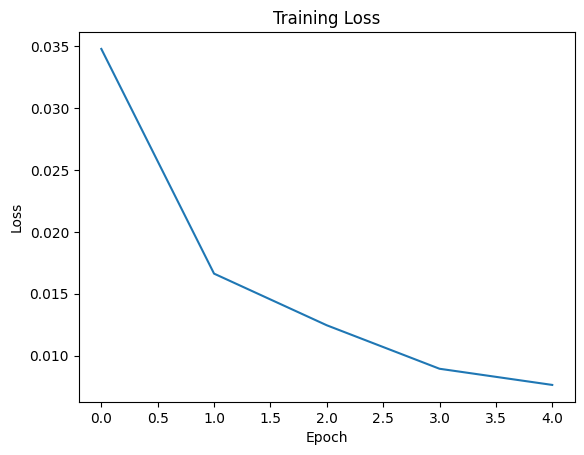

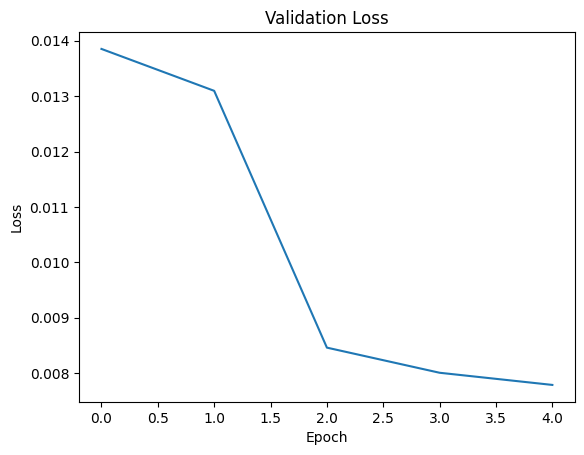

In [41]:
# Plot the loss for both training and validation
plt.title("Training Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.plot(train_history['loss'])
plt.show()

plt.title("Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.plot(train_history['val_loss'])
plt.show()

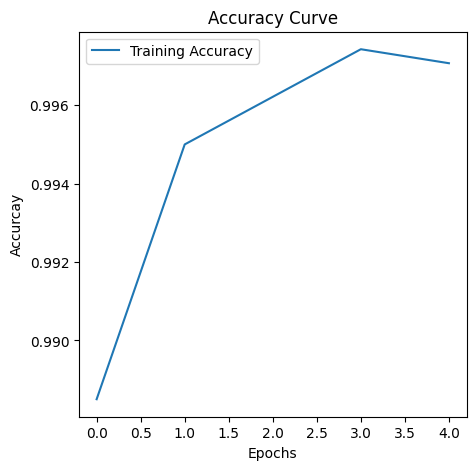

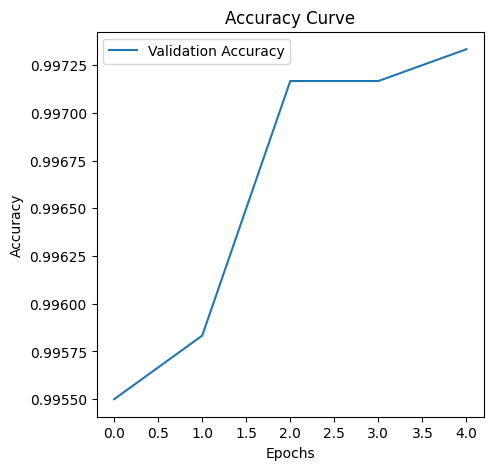

In [42]:
# Plotting accuracy curves for training and validation sets
plt.figure(figsize=(5, 5))
plt.title("Accuracy Curve")
plt.ylabel("Accurcay")
plt.xlabel("Epochs")
plt.plot(train_history['accuracy'], label="Training Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Accuracy Curve")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.plot(train_history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.show()

## 1.6 Model Evaluation

In [43]:
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps= test_generator.samples // test_generator.batch_size
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

187/187 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9965 - loss: 0.0072
Test Loss: 0.0072
Test Accuracy: 0.9965


## 1.7 Visualizing Predictions

In [76]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    batch_size = batch_size,
    target_size = (img_rows, img_cols),
    seed = seed_value,
    class_mode = 'binary',
    shuffle = True
)

Found 6000 images belonging to 2 classes.


In [77]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Function to plot a single image and its prediction
def plot_image_with_title(image, model, true_label, predicted_label, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    # Convert labels from one-hot to class indices if needed, but for binary labels its just 0 or 1
    true_label_name = class_names[true_label]
    pred_label_name = class_names[predicted_label]

    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}")
    plt.axis('off')
    plt.show()

# Function to test the model with images from the test set
def test_model_on_image(test_generator, model, index_to_plot=0):
    # Get a batch of images and labels from the test generator
    test_images, test_labels = next(test_generator)

    # Make predictions on the batch
    predictions = model.predict(test_images)

    # In binary classification, predictions are probabilities (float). Convert to binary (0 or 1)
    predicted_classes = (predictions > 0.5).astype(int).flatten()

    # Get the class indices from the test generator and invert them to get class names
    class_indices = test_generator.class_indices
    class_names = {v: k for k, v in class_indices.items()}  # Invert the dictionary

    # Specify the image to display based on the index
    image_to_plot = test_images[index_to_plot]
    true_label = test_labels[index_to_plot]
    predicted_label = predicted_classes[index_to_plot]

    # Plot the selected image with its true and predicted labels
    plot_image_with_title(image=image_to_plot, model=model, true_label=true_label, predicted_label=predicted_label, class_names=class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


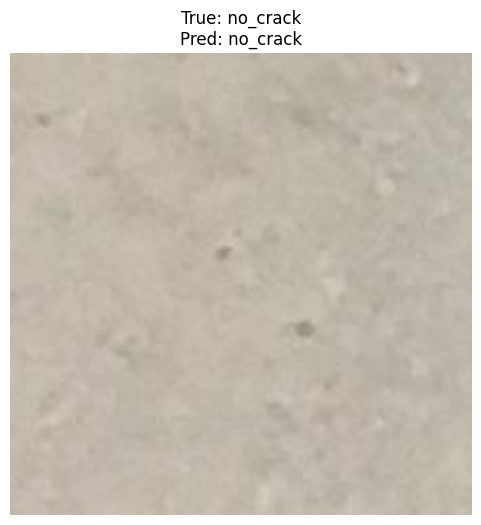

In [89]:
test_model_on_image(test_generator, model, 7)

## 1.8 Test on new image (not in the dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


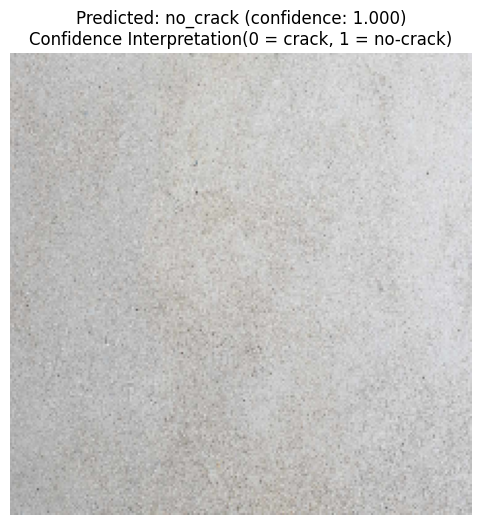

In [99]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_single_image(image_path, model, class_names, target_size=(img_rows, img_cols)):
    # Load image
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0                     # rescale like training
    img_array = np.expand_dims(img_array, axis=0)     # add batch dimension

    # Predict
    prob = model.predict(img_array)[0][0]             # probability of class 1
    pred_class = int(prob > 0.5)
    pred_label = class_names[pred_class]

    # Show the image with prediction
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Predicted: {pred_label} (confidence: {prob:.3f})\nConfidence Interpretation(0 = crack, 1 = no-crack)")
    plt.axis('off')
    plt.show()

# Usage
class_names = {0: 'crack', 1: 'no_crack'}
predict_single_image('no-crack.jpg', model, class_names)